In [1]:
from utils.plotting import *
from utils.auger.fd import NightSkyBackground

21:45:16 (   +7.0s) [INFO   ] -- import logging
21:45:17 (  +151ms) [INFO   ] -- set MONI_PATH = PosixPath('/cr/work/filip/monit_and_sd')
21:45:17 (    +1ms) [INFO   ] -- set HIST_PATH = PosixPath('/cr/work/filip/monit_and_sd')
21:45:17 (    +1ms) [INFO   ] -- set PLOT_PATH = PosixPath('/cr/data01/filip/plots')
21:45:17 (    +1ms) [INFO   ] -- set DATA_PATH = PosixPath('/cr/data01/filip/Data')
21:45:17 (    +0ms) [INFO   ] -- set SCAN_PATH = PosixPath('/cr/data01/filip/xy-calibration')
21:45:17 (    +1ms) [INFO   ] -- set OFLN_PATH = PosixPath('/cr/data01/filip/offline/install')
21:45:17 (  +594ms) [INFO   ] -- import matplotlib.pyplot as plt
21:45:19 (   +1.8s) [INFO   ] -- import seaborn as so
21:45:19 (    +4ms) [INFO   ] -- import numpy as np
21:45:19 (   +15ms) [INFO   ] -- import uncertainties
21:45:19 (    +1ms) [INFO   ] -- import pandas as pd
21:45:19 (    +1ms) [WARNING] -- pandas support to be dropped at some point!
21:45:19 (    +3ms) [INFO   ] -- import binaries.tools as t

In [2]:
# data = {}

# for site in [
#     'LosLeones',
#     'LosMorados',
#     'LomaAmarilla',
#     'Coihueco',
#     'Heat'
#     ]:

#     for tel in range(1, 7 if site != 'Heat' else 4):
#         test = NightSkyBackground.CameraNSB(site, tel)
#         data[f"{site}{tel}"] = len(test.df)

In [2]:
CO4 = NightSkyBackground.CameraNSB("Coihueco", 4)

loading /cr/tempdata01/filip/nsb_data/Coihueco4/nsb_2014-05-01_to_2014-06-01.pkl...
180 files (15.0 yrs) loaded for Coihueco #4


In [ ]:
set_plt_style("slim")

l = []
labels = ['#220 (camera bot.)', '#210 (camera center)', '#199 (camera top)']
for pix in [220, 210, 199]:

    pixel = CO4.get_pixel(pix)
    pixel.show(show_mean=True)

for label, c in zip(labels, ['k', 'r', 'b']):
    l1, = plt.plot([], [], label=label, c=c, ls='-', marker='none')
    l.append(l1)

plt.gca().legend(l, labels, title="Coihueco 4")
plot.save(plt.gcf(), "nsb_thesis_plots/one_pixel")

In [ ]:
from utils.binaries import *

for pix, label in zip([220, 210, 199], ['#220 (camera bot.)', '#210 (camera center)', '#199 (camera top)']):

    pixel = CO4.get_pixel(pix)

    periodogramm = pixel.periodogram(show=False)

    # x, y = periodogramm.power_spectral_density()
    freq, power = periodogramm.autopower(
            minimum_frequency = 1/np.max(periodogramm.t),
            maximum_frequency = 1,
            samples_per_peak = 10,
            # normalization = "psd"
    )

    mask = np.argsort(period := 1/freq)
    x, y = period[mask], power[mask] / 1e3

    plt.plot(x, y, marker='none', label=label)

# plt.axvline(365.25, c='k', ls='--', lw=0.4)
# plt.axvline(365.25/2, c='k', ls='--', lw=0.4)
# plt.axvspan(21, 42, ec='none', fc='k', alpha=0.2)

# xmin, xmax = plt.gca().get_xlim()
# plt.axvspan(3500, xmax, ec='none', fc='k', alpha=0.2)

# plt.legend(loc='upper left')
ax = plt.gca()
ax.set_xscale("log") 
# ax.set_xlim(0.7, xmax)

# ax.text(
#     21, 195,
#     "moon cycles",
#     rotation=90,
#     ha='right', va='top'
# )

# ax.text(
#     365.25/2, 195,
#     r"$6$ months",
#     rotation=90,
#     ha='right', va='top'
# )

# ax.text(
#     365.25, 195,
#     r"$1$ year",
#     rotation=90,
#     ha='right', va='top'
# )

# ax.text(
#     3500, 195,
#     r"FD ageing",
#     rotation=90,
#     ha='right', va='top'
# )

# ax.set_xlabel('Period / $\mathrm{day}$')
# ax.set_ylabel(r"PSD / $\frac{\mathrm{ADC}^2}{\mathrm{mHz}}$")
# # plot.save(plt.gcf(), "nsb_thesis_plots/one_pixel_psd")

In [ ]:


for pix, label in zip([220, 210, 199], 
                      ['#220 (camera bot.)', '#210 (camera center)', '#199 (camera top)']):

    pixel = CO4.get_pixel(pix)

    model, peaks, amplitudes = pixel.get_model(show=True, return_peaks=True, n_peaks=6, height=20)

21:11:34 ( +572.2s) [DEBUG  ] -- font size set to 9.5
21:11:34 (    +2ms) [DEBUG  ] -- label size set to 13.0
21:11:34 (    +1ms) [DEBUG  ] -- figure size set to [6.6, 2.2]
21:11:34 (    +1ms) [DEBUG  ] -- markersize set to 2.0
21:11:34 (    +1ms) [DEBUG  ] -- usetex set to False


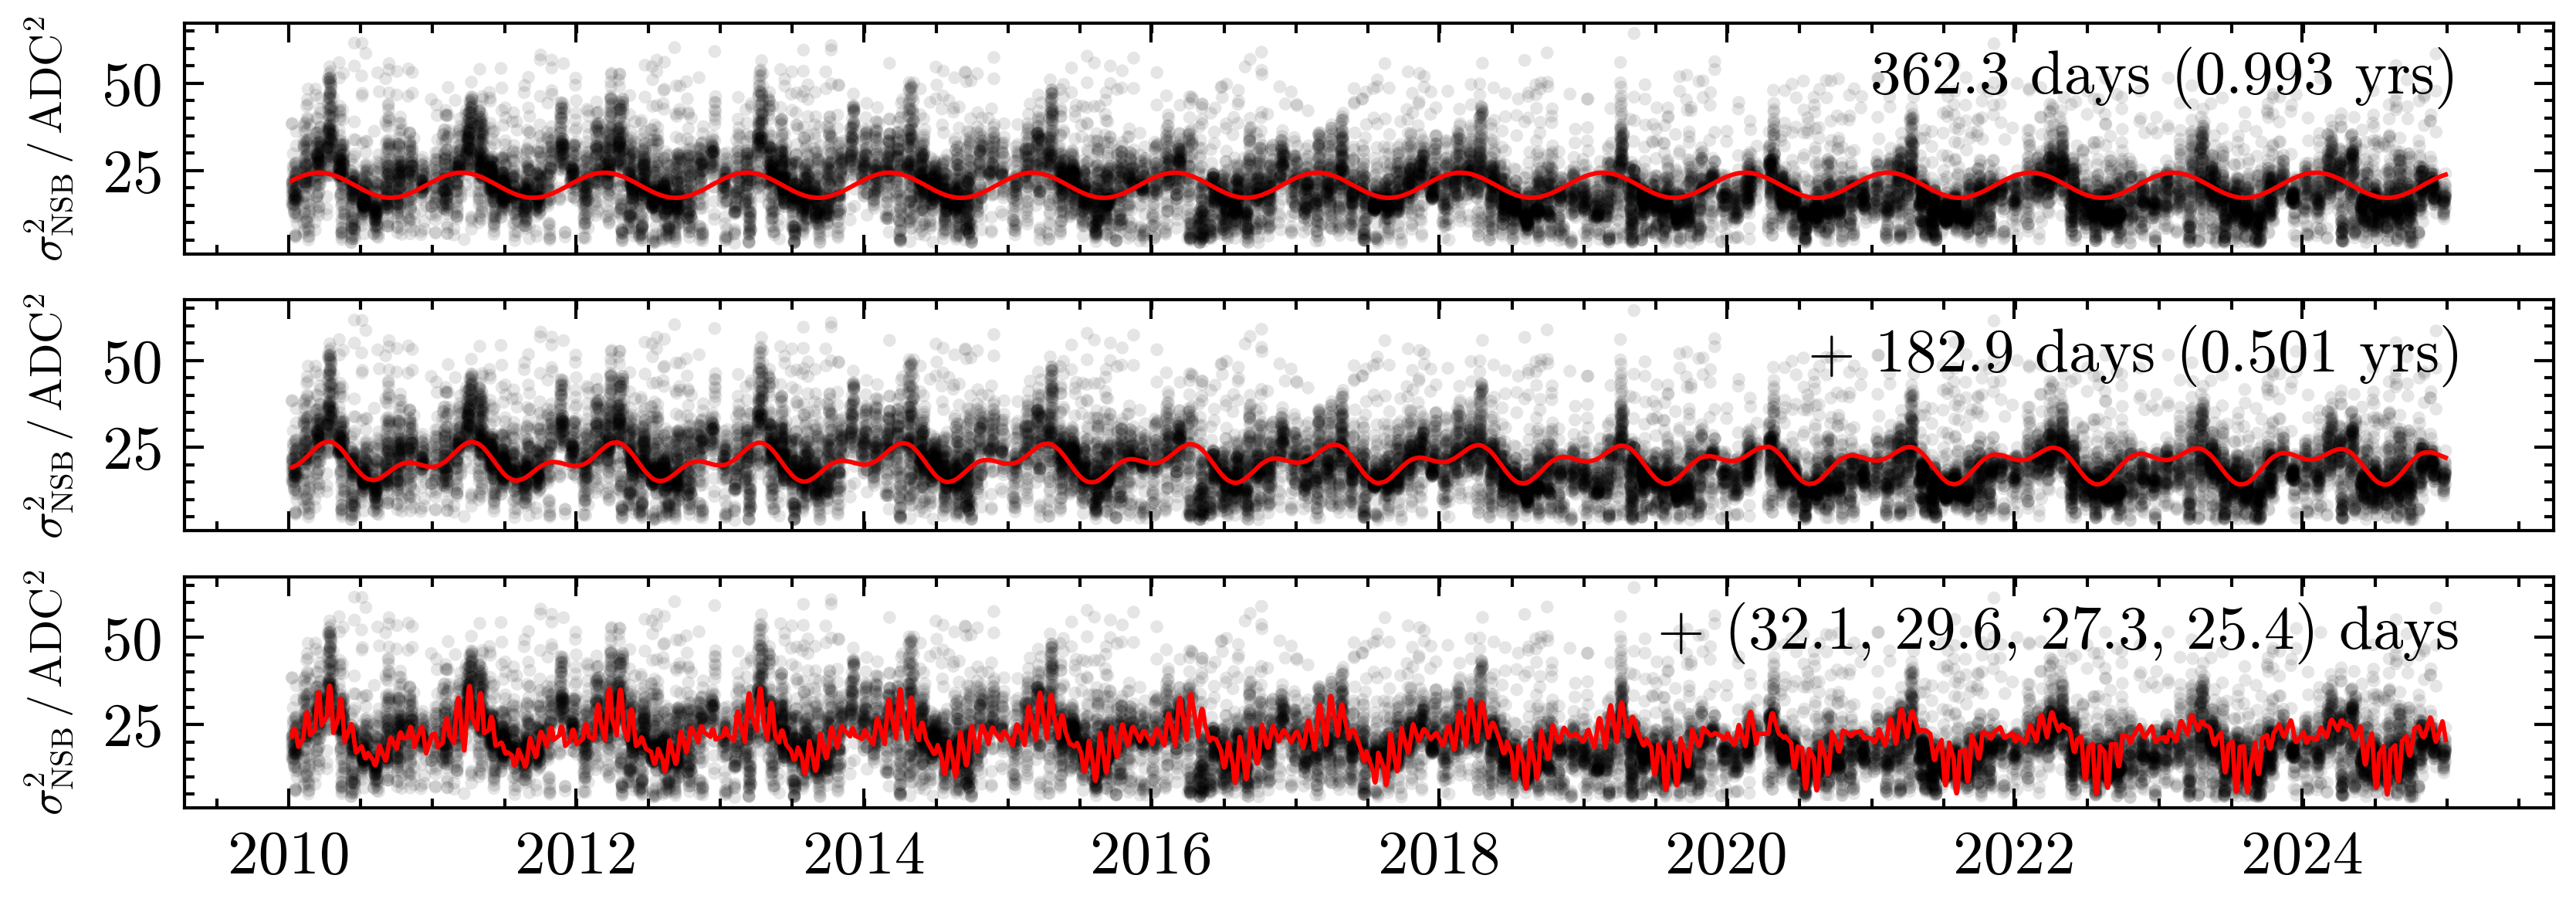

In [4]:
from datetime import datetime
from utils.binaries import *

set_plt_style("slim")

start, stop = datetime(2010, 1, 1).timestamp(), datetime(2024, 12, 31).timestamp()
X = np.linspace(start, stop)

fig, axes = plt.subplots(3, 1, sharex=True, sharey=True)
pixel210 = CO4.get_pixel(210)

for n, ax in zip([1, 2, 6], axes):
    model, peaks, amplitudes = pixel210.get_model(show=False, return_peaks=True, return_amplitudes=True, n_peaks=n, height=20)

    # pixel210.show(ax=ax, show_mean=True)
    ax.scatter(pixel210.df['datetime'], pixel210.df['night_sky_background'], alpha=0.1, ec='none')
    ax.plot(pixel210.df['datetime'], model(pixel210.df['days_since_start']), marker='none', lw=0.7, c='r')

    if n == 6:
        fmt = "(" +f", ".join([f"{d:.1f}" for d in 1/np.array(peaks[2:])]) + ") days"
    else:
        fmt = f"{1/peaks[-1]:.1f} days ({1/peaks[-1]/365:.3f} yrs)" if 1/peaks[-1]>180 else f"{1/peaks[-1]:.1f} days"

    ax.set_ylabel("$\sigma^2_\mathrm{NSB}\,/\,\mathrm{ADC}^2$", fontsize=7)
    ax.text(
        0.96, 0.9,
        fmt if n == 1 else "$+$ " + fmt,
        transform=ax.transAxes,
        va='top', ha='right'
    )

plot.apply_datetime_format(ax)
plot.save(fig, "nsb_thesis_plots/sinusoidal_model")

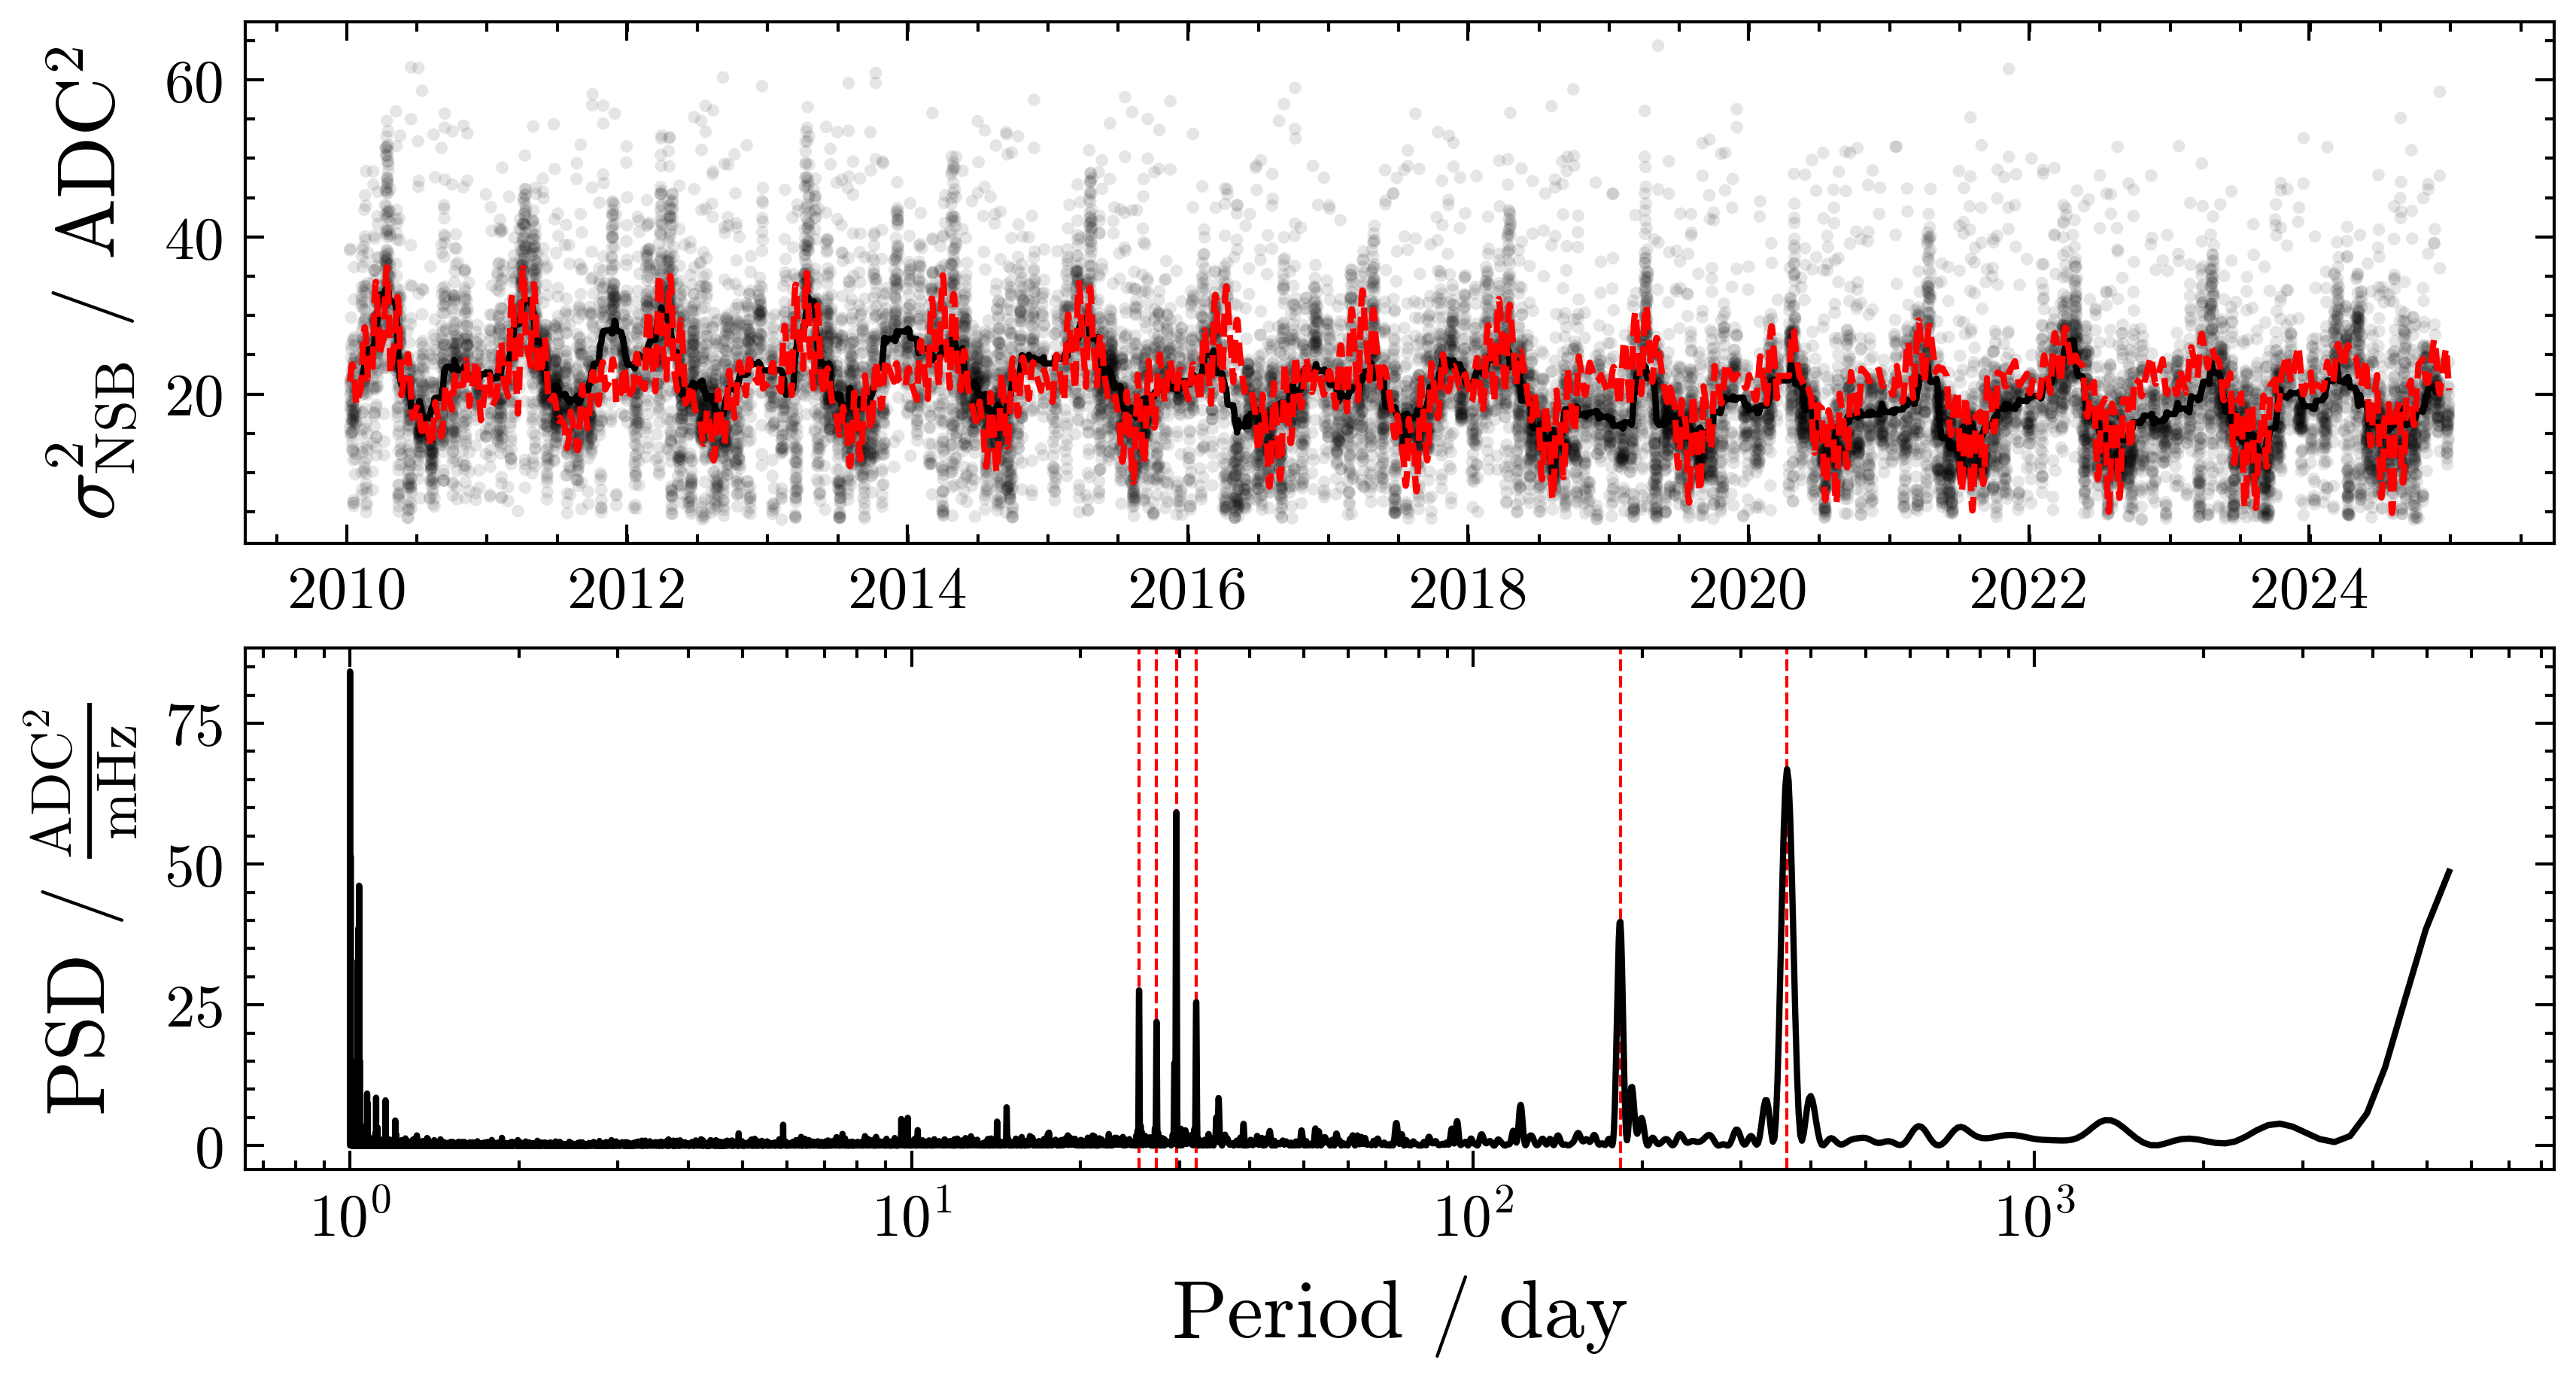

In [6]:
pixel210 = CO4.get_pixel(210)

_, freq, _ = pixel210.get_model(show=True, return_peaks=True, return_amplitudes=True, n_peaks=6, height=20)

In [20]:
periodogram = pixel210._periodogram

for k, f in enumerate(freq, 1):
    array = periodogram.model_parameters(f)
    print(f"$k = {k}$ & ${1/f:.2f}$ & ${array[1]:.4f}$ & ${array[2]:.4f}$ \\\\")

$k = 1$ & $362.26$ & $3.3648$ & $1.3141$ \\
$k = 2$ & $182.95$ & $-0.8216$ & $-2.6550$ \\
$k = 3$ & $32.14$ & $0.9096$ & $2.0422$ \\
$k = 4$ & $29.62$ & $3.3568$ & $0.5773$ \\
$k = 5$ & $27.31$ & $1.2418$ & $-1.6838$ \\
$k = 6$ & $25.42$ & $-2.1036$ & $0.9739$ \\


In [21]:
pixel210.df['night_sky_background'].mean()

np.float64(20.395883920365613)